# **R/S benchmark — PCE validation plots**

## **1. Libraries**

In [1]:
%matplotlib inline
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import dill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import matplotlib.ticker as ticker

from functions import *

/home/casa-wand/steam2tb/2024-1_victor_hugo_renata_maria/.venv/lib/python3.11/site-packages/UQpy/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## **2. Config**

`n_latent_samples` and `times` must match [`01_generate_dataset.ipynb`](01_generate_dataset.ipynb)
/ [`02_train_pce.ipynb`](02_train_pce.ipynb) — together they name the files being loaded.

In [2]:
n_latent_samples = 2500   # must match stage 1/2 — it names the files being loaded
times            = np.linspace(0, 100, 5, endpoint=True)   # must match stage 1/2

fig_size   = (5, 4)      # size of each individual figure, in inches
fig_format = 'png'       # format each figure is saved in ('pdf', 'png', ...)
fig_dpi    = 300         # resolution the figure is saved at (dots per inch)

label_fontsize = 14   # font size of the axis labels
tick_fontsize  = 12   # font size of the tick numbers

## **3. Emulator efficiency (speed-up)**

Loads each time step's PCE metamodel and `dataset_unique_train` fresh, and times a prediction on
the training points against the emulator cost recorded by
[`01_generate_dataset.ipynb`](01_generate_dataset.ipynb).

In [3]:
with open(f'{n_latent_samples}_emulator_timing_benchmark.pkl', 'rb') as f:
    emulator_timing = dill.load(f)

speedup_rows = []
for t in times:
    with open(f'{n_latent_samples}_pce_metamodel_{t}_benchmark.pkl', 'rb') as f:
        pce_metamodel = dill.load(f)
    with open(f'{n_latent_samples}_dataset_unique_train_{t}_benchmark.pkl', 'rb') as f:
        df_unique_train = dill.load(f)
    x_train = df_unique_train[['r', 's']].to_numpy()

    emulator_s = float(emulator_timing.loc[emulator_timing['Time (years)'] == t, 'Train total (s)'].iloc[0])

    t_start = time.perf_counter()
    pce_metamodel.predict(x_train)
    surrogate_s = time.perf_counter() - t_start

    speedup_rows.append({
                            'Time (years)':  t,
                            'Emulator (s)':  emulator_s,
                            'Surrogate (s)': surrogate_s,
                            'Speed-up':      emulator_s / surrogate_s,
                        })

speedup = pd.DataFrame(speedup_rows)
print(f"Median speed-up: {speedup['Speed-up'].median():,.0f}x")
speedup

Median speed-up: 556,504x


,Time (years),Emulator (s),Surrogate (s),Speed-up
0,0.0,936.209381,0.002231,419549.399274
1,25.0,954.884701,0.001499,637069.302140
2,50.0,905.878127,0.001637,553220.179169
3,75.0,870.398033,0.001492,583322.744344
4,100.0,798.989566,0.001436,556503.666716


### 3.1 Speed-up over time

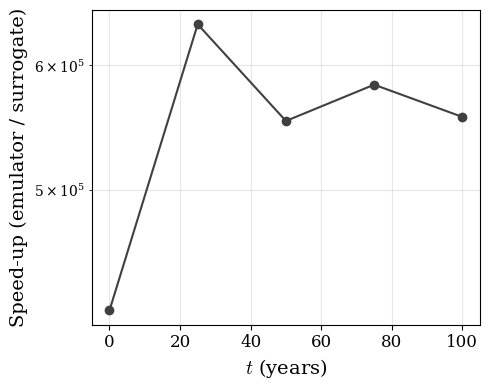

In [4]:
fig, ax = plt.subplots(figsize=fig_size)
ax.plot(speedup['Time (years)'], speedup['Speed-up'], marker='o', color='0.25')
ax.set_xlabel('$t$ (years)', fontsize=label_fontsize)
ax.set_ylabel('Speed-up (emulator / surrogate)', fontsize=label_fontsize)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v:,.0f}x'))
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()

fig.savefig(f'{n_latent_samples}_speedup_benchmark.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

## **4. PCE validation via KL divergence**

Spot-checks one design point against the PCE, straight against the **raw** Monte Carlo `g` samples
of that point (`dataset_full`), with no GLD fitted to them first — so the score is the PCE's own
error, without pyGLAM's fitting error stacked on top. The reference density is a KDE of the raw
data; the PCE side is the GLD built from the PCE's `lambda 1`/`lambda 2` plus the `lambda3`/`lambda4`
written by hand below.

`time_index` and `design_point_index` pick which point to check, both by position — so they're
guaranteed to exist in the saved dataset, rather than typing an `(R, S)` that might not be one of
the points actually simulated.

In [5]:
time_index         = 2   # index into `times` — which time step's PCE to check
design_point_index = 0   # row index into that time step's dataset_unique_train — which (R, S) to check

lambda3 = 0.142157   # written by hand — the PCE's own lambda 3 / lambda 4 are unreliable
lambda4 = 0.131525

n_grid = 400   # grid points used to numerically integrate the KL divergence and R²

xlim = None   # e.g. (-5, 15) to fix the g axis; None = auto-scaled to the data
ylim = None   # e.g. (0, 1) to fix the density axis; None = auto-scaled to the data

In [6]:
t_check = times[time_index]

with open(f'{n_latent_samples}_dataset_full_train_{t_check}_benchmark.pkl', 'rb') as f:
    df_full_check = dill.load(f)
with open(f'{n_latent_samples}_dataset_unique_train_{t_check}_benchmark.pkl', 'rb') as f:
    df_unique_check = dill.load(f)
with open(f'{n_latent_samples}_pce_metamodel_{t_check}_benchmark.pkl', 'rb') as f:
    pce_metamodel = dill.load(f)

design_point = df_unique_check.iloc[design_point_index]
r_check, s_check = design_point['r'], design_point['s']

g_real = df_full_check.loc[(df_full_check['r'] == r_check) & (df_full_check['s'] == s_check), 'g'].to_numpy()

print(f"Checking t = {t_check:.2f} years, R = {r_check:.3f}, S = {s_check:.3f} ({len(g_real)} raw g samples)")

kl_result = validate_pce_kl_divergence_benchmark(
                                                    pce_metamodel=pce_metamodel,
                                                    r=r_check,
                                                    s=s_check,
                                                    g_real=g_real,
                                                    lambda3=lambda3,
                                                    lambda4=lambda4,
                                                    n_grid=n_grid,
                                                  )

print(f"KL divergence:  {kl_result['kl_divergence']:.5f}")
print(f"KS statistic:   {kl_result['ks_statistic']:.5f}")
print(f"Wasserstein:    {kl_result['wasserstein']:.5f}")
print(f"R2 (PDFs):      {kl_result['r2_pdf']:.5f}")
print(f"Rel. error P5:  {kl_result['rel_err_p5']:+.2%}")
print(f"Rel. error P50: {kl_result['rel_err_p50']:+.2%}")
print(f"Rel. error P95: {kl_result['rel_err_p95']:+.2%}")

Checking t = 50.00 years, R = 5.394, S = 2.305 (2500 raw g samples)
KL divergence:  0.00374
KS statistic:   0.01840
Wasserstein:    0.00540
R2 (PDFs):      0.99791
Rel. error P5:  -0.47%
Rel. error P50: -0.16%
Rel. error P95: +0.18%


### 4.1 Chart in english

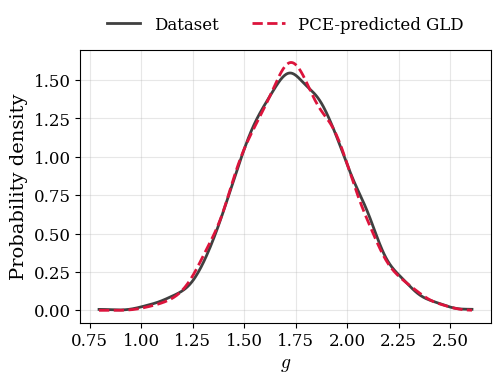

In [7]:
pkl_name = f'{n_latent_samples}_dataset_unique_train_{t_check}_benchmark'

fig, ax = plt.subplots(figsize=fig_size)
ax.plot(kl_result['x_grid'], kl_result['pdf_real'], color='0.25', linewidth=2, label='Dataset')
ax.plot(kl_result['x_grid'], kl_result['pdf_pce'], color='crimson', linewidth=2, linestyle='--', label='PCE-predicted GLD')
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim is not None:
    ax.set_xlim(xlim)
if ylim is not None:
    ax.set_ylim(ylim)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize=tick_fontsize, frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_kl_divergence_R{r_check:g}_S{s_check:g}_{t_check}_en.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 4.2 Chart in portuguese

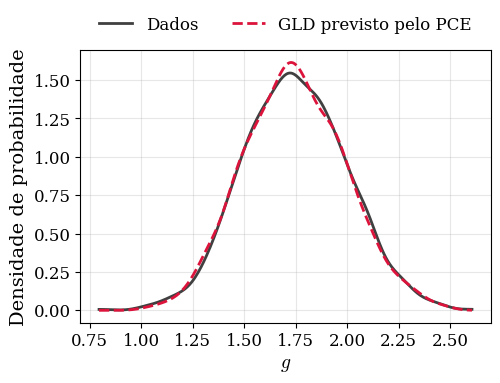

In [8]:
fig, ax = plt.subplots(figsize=fig_size)
ax.plot(kl_result['x_grid'], kl_result['pdf_real'], color='0.25', linewidth=2, label='Dados')
ax.plot(kl_result['x_grid'], kl_result['pdf_pce'], color='crimson', linewidth=2, linestyle='--', label='GLD previsto pelo PCE')
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Densidade de probabilidade', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim is not None:
    ax.set_xlim(xlim)
if ylim is not None:
    ax.set_ylim(ylim)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize=tick_fontsize, frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name}_kl_divergence_R{r_check:g}_S{s_check:g}_{t_check}_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 4.3 Second time check — same $(R, S)$, another $t$

Repeats section 4 at a **second** time step, on the **same** design point, so the two can be read
side by side: does the PCE still track the raw data once the structure has aged?

The design samples are drawn once in [`01_generate_dataset.ipynb`](01_generate_dataset.ipynb) and
reused at every time step, so `design_point_index` lands on the same $(R, S)$ here as in section 4 —
the cell below prints both and warns if they ever drift apart.

In [9]:
time_index_b = 4   # index into `times` — the second time step to check (section 4 used `time_index`)

lambda3_b = lambda3   # same hand-written lambda 3 / lambda 4 as section 4
lambda4_b = lambda4

In [10]:
t_check_b = times[time_index_b]

with open(f'{n_latent_samples}_dataset_full_train_{t_check_b}_benchmark.pkl', 'rb') as f:
    df_full_check_b = dill.load(f)
with open(f'{n_latent_samples}_dataset_unique_train_{t_check_b}_benchmark.pkl', 'rb') as f:
    df_unique_check_b = dill.load(f)
with open(f'{n_latent_samples}_pce_metamodel_{t_check_b}_benchmark.pkl', 'rb') as f:
    pce_metamodel_b = dill.load(f)

design_point_b = df_unique_check_b.iloc[design_point_index]
r_check_b, s_check_b = design_point_b['r'], design_point_b['s']

if not (np.isclose(r_check_b, r_check) and np.isclose(s_check_b, s_check)):
    print(f"WARNING: design point {design_point_index} is not the same at both times — "
          f"(R = {r_check:.3f}, S = {s_check:.3f}) at t = {t_check:.2f} vs "
          f"(R = {r_check_b:.3f}, S = {s_check_b:.3f}) at t = {t_check_b:.2f}")

g_real_b = df_full_check_b.loc[(df_full_check_b['r'] == r_check_b) & (df_full_check_b['s'] == s_check_b), 'g'].to_numpy()

print(f"Checking t = {t_check_b:.2f} years, R = {r_check_b:.3f}, S = {s_check_b:.3f} ({len(g_real_b)} raw g samples)")

kl_result_b = validate_pce_kl_divergence_benchmark(
                                                      pce_metamodel=pce_metamodel_b,
                                                      r=r_check_b,
                                                      s=s_check_b,
                                                      g_real=g_real_b,
                                                      lambda3=lambda3_b,
                                                      lambda4=lambda4_b,
                                                      n_grid=n_grid,
                                                    )

print(f"KL divergence:  {kl_result_b['kl_divergence']:.5f}")
print(f"KS statistic:   {kl_result_b['ks_statistic']:.5f}")
print(f"Wasserstein:    {kl_result_b['wasserstein']:.5f}")
print(f"R2 (PDFs):      {kl_result_b['r2_pdf']:.5f}")
print(f"Rel. error P5:  {kl_result_b['rel_err_p5']:+.2%}")
print(f"Rel. error P50: {kl_result_b['rel_err_p50']:+.2%}")
print(f"Rel. error P95: {kl_result_b['rel_err_p95']:+.2%}")

Checking t = 100.00 years, R = 5.394, S = 2.305 (2500 raw g samples)
KL divergence:  0.00366
KS statistic:   0.01400
Wasserstein:    0.00701
R2 (PDFs):      0.99753
Rel. error P5:  +10.91%
Rel. error P50: +0.32%
Rel. error P95: +1.11%


### 4.4 Chart in english — second time

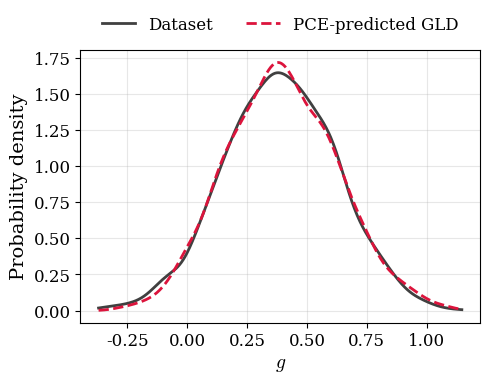

In [11]:
pkl_name_b = f'{n_latent_samples}_dataset_unique_train_{t_check_b}_benchmark'

fig, ax = plt.subplots(figsize=fig_size)
ax.plot(kl_result_b['x_grid'], kl_result_b['pdf_real'], color='0.25', linewidth=2, label='Dataset')
ax.plot(kl_result_b['x_grid'], kl_result_b['pdf_pce'], color='crimson', linewidth=2, linestyle='--', label='PCE-predicted GLD')
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim is not None:
    ax.set_xlim(xlim)
if ylim is not None:
    ax.set_ylim(ylim)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize=tick_fontsize, frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name_b}_kl_divergence_R{r_check_b:g}_S{s_check_b:g}_{t_check_b}_en.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 4.5 Chart in portuguese — second time

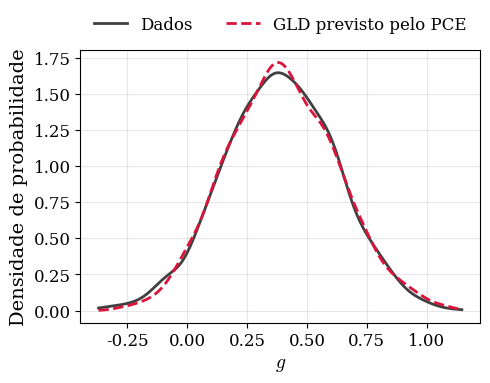

In [12]:
fig, ax = plt.subplots(figsize=fig_size)
ax.plot(kl_result_b['x_grid'], kl_result_b['pdf_real'], color='0.25', linewidth=2, label='Dados')
ax.plot(kl_result_b['x_grid'], kl_result_b['pdf_pce'], color='crimson', linewidth=2, linestyle='--', label='GLD previsto pelo PCE')
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Densidade de probabilidade', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim is not None:
    ax.set_xlim(xlim)
if ylim is not None:
    ax.set_ylim(ylim)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize=tick_fontsize, frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name_b}_kl_divergence_R{r_check_b:g}_S{s_check_b:g}_{t_check_b}_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 4.6 The two times side by side

The same $(R, S)$ at both instants, in one table and one figure: the density drifts left as $k(t)$
eats into the resistance, and the PCE curve is expected to follow it at both ends of the interval.

In [13]:
stat_keys = {
                'KL':             'kl_divergence',
                'KS':             'ks_statistic',
                'Wasserstein':    'wasserstein',
                'R2 (PDF)':       'r2_pdf',
                'Rel. error P5':  'rel_err_p5',
                'Rel. error P50': 'rel_err_p50',
                'Rel. error P95': 'rel_err_p95',
            }

two_times = pd.DataFrame([
                             {'Time (years)': t_c, 'r': r_c, 's': s_c,
                              **{label: res[key] for label, key in stat_keys.items()}}
                             for t_c, r_c, s_c, res in [(t_check,   r_check,   s_check,   kl_result),
                                                        (t_check_b, r_check_b, s_check_b, kl_result_b)]
                         ])

two_times

,Time (years),r,s,KL,KS,Wasserstein,R2 (PDF),Rel. error P5,Rel. error P50,Rel. error P95
0,50.0,5.394279,2.305431,0.003738,0.0184,0.005402,0.997909,-0.004714,-0.001590,0.001773
1,100.0,5.394279,2.305431,0.003659,0.0140,0.007014,0.997527,0.109101,0.003181,0.011063


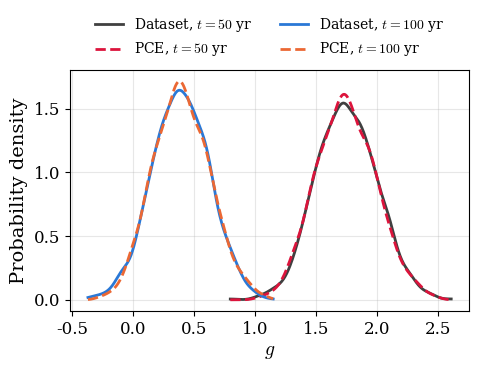

In [14]:
fig, ax = plt.subplots(figsize=fig_size)
ax.plot(kl_result['x_grid'],   kl_result['pdf_real'],   color='0.25',    linewidth=2,                   label=f'Dataset, $t = {t_check:g}$ yr')
ax.plot(kl_result['x_grid'],   kl_result['pdf_pce'],    color='crimson', linewidth=2, linestyle='--',   label=f'PCE, $t = {t_check:g}$ yr')
ax.plot(kl_result_b['x_grid'], kl_result_b['pdf_real'], color='#2a78d6', linewidth=2,                   label=f'Dataset, $t = {t_check_b:g}$ yr')
ax.plot(kl_result_b['x_grid'], kl_result_b['pdf_pce'],  color='#eb6834', linewidth=2, linestyle='--',   label=f'PCE, $t = {t_check_b:g}$ yr')
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim is not None:
    ax.set_xlim(xlim)
if ylim is not None:
    ax.set_ylim(ylim)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.28), ncol=2, fontsize=tick_fontsize - 2, frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{n_latent_samples}_kl_divergence_R{r_check:g}_S{s_check:g}_t{t_check:g}_vs_t{t_check_b:g}_en.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

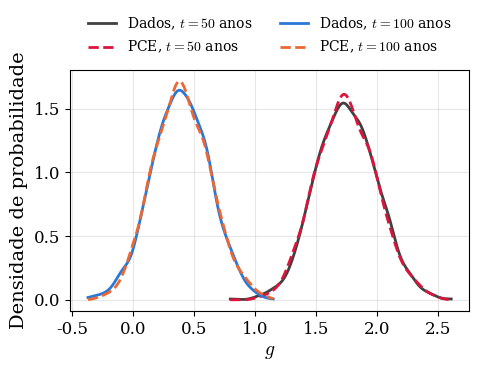

In [15]:
fig, ax = plt.subplots(figsize=fig_size)
ax.plot(kl_result['x_grid'],   kl_result['pdf_real'],   color='0.25',    linewidth=2,                   label=f'Dados, $t = {t_check:g}$ anos')
ax.plot(kl_result['x_grid'],   kl_result['pdf_pce'],    color='crimson', linewidth=2, linestyle='--',   label=f'PCE, $t = {t_check:g}$ anos')
ax.plot(kl_result_b['x_grid'], kl_result_b['pdf_real'], color='#2a78d6', linewidth=2,                   label=f'Dados, $t = {t_check_b:g}$ anos')
ax.plot(kl_result_b['x_grid'], kl_result_b['pdf_pce'],  color='#eb6834', linewidth=2, linestyle='--',   label=f'PCE, $t = {t_check_b:g}$ anos')
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Densidade de probabilidade', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim is not None:
    ax.set_xlim(xlim)
if ylim is not None:
    ax.set_ylim(ylim)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.28), ncol=2, fontsize=tick_fontsize - 2, frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{n_latent_samples}_kl_divergence_R{r_check:g}_S{s_check:g}_t{t_check:g}_vs_t{t_check_b:g}_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

## **5. Error maps over the whole dataset**

Sweeps every design point of every time step: for each one, scores the PCE's predicted GLD against
that point's own raw Monte Carlo `g` samples, and records the seven statistics. The result is one
row per (design point, time step) — saved as a `.pkl` so it can be reused elsewhere — plus a matrix
of scatter maps: one row per time step, one column per statistic, coloured by that statistic.

Each column shares one colour scale across all time steps, so a column can be read top-to-bottom as
"does this error grow with age?". The colour limits are percentile-clipped and the colour bars are
drawn with arrow caps, marking that some points run past the ends of the scale.

Two things worth knowing when reading the relative-error columns:

- they blow up where the reference percentile itself sits near zero — which is exactly what happens
  along the $R$–$S$ line where $g$'s median crosses zero as the structure degrades, so the streaks
  visible there are an artefact of dividing by something small, not of the PCE being wrong there;
- a handful of points score NaN and simply do not appear: at $t = 133$ and $t = 150$ the PCE
  extrapolates to $\lambda_2 \le 0$ at a few extreme-$S$ points, which is not a valid GLD at all.

In [16]:
# lambda3_sweep = 0.134    # same hand-written lambda 3 / lambda 4 as section 4
# lambda4_sweep = 0.128

# split_sweep      = 'train'   # 'train' or 'val'
# n_grid_sweep     = 400
# max_points_sweep = 10        # random subsample of design points. None scores all ~2000, which costs about 90 s per time step

# cell_w, cell_h  = 2.6, 2.2   # size of each panel of the matrix, in inches
# fig_dpi_matrix  = 150        # the matrix is large — 300 dpi would make a very heavy file

# # Colour limits are percentile-clipped, otherwise a handful of extreme points flatten every map.
# # The relative errors need a much tighter clip than the rest: their median is well under 1%, but
# # they run to several thousand per cent where the reference percentile sits near zero.
# clip_pct_sequential = 99   # KL, KS, Wasserstein, R2
# clip_pct_diverging  = 90   # the three relative errors

In [17]:
# sweep_frames = []
# for t in times:
#     with open(f'{n_latent_samples}_dataset_full_{split_sweep}_{t}_benchmark.pkl', 'rb') as f:
#         df_full_t = dill.load(f)
#     with open(f'{n_latent_samples}_pce_metamodel_{t}_benchmark.pkl', 'rb') as f:
#         pce_metamodel_t = dill.load(f)

#     sweep_frames.append(validate_pce_kl_divergence_dataset_benchmark(
#                                                                         pce_metamodel=pce_metamodel_t,
#                                                                         df_full=df_full_t,
#                                                                         time_step=t,
#                                                                         lambda3=lambda3_sweep,
#                                                                         lambda4=lambda4_sweep,
#                                                                         n_grid=n_grid_sweep,
#                                                                         max_points=max_points_sweep,
#                                                                     ))
#     del df_full_t

# pce_error_maps = pd.concat(sweep_frames, ignore_index=True)

# with open(f'{n_latent_samples}_pce_error_maps_benchmark.pkl', 'wb') as f:
#     dill.dump(pce_error_maps, f)

# print(f"\n{len(pce_error_maps)} rows saved to {n_latent_samples}_pce_error_maps_benchmark.pkl")
# pce_error_maps.head()

### 5.1 Summary per time step

In [18]:
# stat_cols = ['KL', 'KS', 'Wasserstein', 'R2 (PDF)', 'Rel. error P5', 'Rel. error P50', 'Rel. error P95']

# pce_error_maps.groupby('Time (years)')[stat_cols].mean()

### 5.2 Matrix of error maps

In [19]:
# diverging_cols = {'Rel. error P5', 'Rel. error P50', 'Rel. error P95'}

# fig, axes = plt.subplots(len(times), len(stat_cols),
#                           figsize=(cell_w * len(stat_cols), cell_h * len(times)),
#                           sharex=True, sharey=True, layout='constrained')

# for j, col in enumerate(stat_cols):
#     values = pce_error_maps[col].to_numpy()
#     if col in diverging_cols:
#         limit     = np.nanpercentile(np.abs(values), clip_pct_diverging)
#         vmin, vmax, cmap = -limit, limit, 'coolwarm'
#     else:
#         vmin = np.nanpercentile(values, 100 - clip_pct_sequential)
#         vmax = np.nanpercentile(values, clip_pct_sequential)
#         cmap = 'viridis'

#     for i, t in enumerate(times):
#         ax  = axes[i, j]
#         sub = pce_error_maps[pce_error_maps['Time (years)'] == t]
#         sc  = ax.scatter(sub['r'], sub['s'], c=sub[col], cmap=cmap, vmin=vmin, vmax=vmax, s=5)
#         ax.tick_params(axis='both', labelsize=tick_fontsize - 4)
#         ax.grid(True, alpha=0.2)
#         if j == 0:
#             ax.set_ylabel(f'$t={t:.0f}$ yr', fontsize=tick_fontsize)

#     cbar = fig.colorbar(sc, ax=axes[:, j].tolist(), location='top', shrink=0.9, extend='both')
#     cbar.set_label(col, fontsize=tick_fontsize)

# fig.supxlabel('$R$', fontsize=label_fontsize)
# fig.supylabel('$S$', fontsize=label_fontsize)

# fig.savefig(f'{n_latent_samples}_pce_error_maps_benchmark.{fig_format}', bbox_inches='tight', dpi=fig_dpi_matrix)
# plt.show()